# Compute a covariance analogous to DES × Planck

The likelihood's supplied covariance has 1,809 entries. This generator computes its first 1,500, the galaxy/shear entries. The likelihood mask, the dataset's list of 0/1 flags that applies the scale cuts, retains 635 of them; they form the supported 3×2pt submatrix of cosmic shear $\xi_\pm$, galaxy–galaxy lensing $\gamma_t$ and galaxy clustering $w$. The CMB-lensing observables need their own models (reconstruction noise, filtering of the lensing map, bandpower binning), so their auto- and cross-covariances are not generated. The likelihood keeps using the supplied full joint matrix.

This notebook computes the Gaussian (G), super-sample (SSC) and connected non-Gaussian (cNG) covariance and their total separately. It then reads the project's supplied matrix and applies **the same likelihood mask** to both. The comparison concerns analogous measurements; it is not a reproduction of the supplied covariance. No likelihood data file is overwritten and no covariance is installed in the compiled library.

| Measurement choice | Value |
| --- | --- |
| Dataset | [data/Y3xPlanckPR4.dataset](data/Y3xPlanckPR4.dataset) |
| Lens / source bins | 6 / 4 |
| Bins per two-point observable | 30, 0.25–250 arcmin |
| Generated entries before cuts | 1,500 |
| Entries after the selected likelihood mask | 635 |

The forecast uses massless neutrinos, linear galaxy bias, zero magnification and redshift-space distortions (RSD), and a spherical-cap footprint: a circular patch of sky with the survey's area.

Gaussian galaxy–galaxy and galaxy–shear spectra include non-Limber corrections; shear–shear remains Limber. The Limber approximation evaluates each multipole $\ell$ at the single wavenumber $k=(\ell+1/2)/\chi$ at each comoving distance $\chi$; it is least accurate for narrow redshift bins at low $\ell$. Gaussian intrinsic alignment (IA), with the nonlinear-alignment (NLA) or tidal-alignment-and-tidal-torquing (TATT) model, is optional below.

SSC/cNG retain their zero-IA Limber model. SSC uses the isotropic halo response and cNG the halo trispectrum. Massive-neutrino non-Gaussian terms are not implemented.

These physical choices differ from the supplied likelihood matrices. Matching their measurement layout does not establish physical or numerical equivalence.

The [covariance guide](covariance/README.md) explains survey inputs and how to start Jupyter. The decomposition follows [Krause & Eifler, Appendix A](https://arxiv.org/abs/1601.05779) and [Takada & Hu](https://arxiv.org/abs/1302.6994). Covariance generation is excluded from the default build. Follow the [project build steps](README.md#computing_covariances): after activating Cocoa, unset `IGNORE_COSMOLIKE_DESXPLANCK_COVARIANCE` and recompile this project. Then restart the notebook kernel, the Python process that runs these cells: an already imported compiled module is not reloaded.

In [1]:
import os
from pathlib import Path
import sys

# BLAS stays serial; the compiled CosmoLike loops own the OpenMP workers.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
root = Path(os.environ["ROOTDIR"])
project = root/"projects/desy1xplanck"
sys.path.insert(0, str(root/"external_modules/code/cosmolike_core"))
sys.path.insert(0, str(root/"external_modules/code/CAMB"))
sys.path.insert(0, str(project/"interface"))
sys.path.insert(0, str(project/"covariance"))

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from threadpoolctl import threadpool_limits
import cosmolike_desy1xplanck_interface as ci
import desy1xplanck_covariance as survey
from cosmolike_notebook_utils import covariance as cov
from cosmolike_notebook_utils import plot_covariances as pcov
from cosmolike_notebook_utils.covariance.likelihood import (
    read_likelihood_covariance,
    select_likelihood_entries,
)
from cosmolike_notebook_utils.covariance.forecast import save_forecast

blas_limit = threadpool_limits(limits=1, user_api="blas")
ci.set_omp_threads(n=8)
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"

## Choose the measurement and numerical settings

The default run computes the project's native measurement, real space, once at boost 1. Set `boosts = [1, 2]` to add the numerical comparison below. `spaces = ["real", "fourier"]` also computes Fourier-space bandpowers; that companion space is illustrative and is not compared to the supplied matrix.

`accuracy_boost` multiplies the internal interpolation refinements and multipole cutoffs in [covariance/default.yaml](covariance/default.yaml). The default power tables have 11,993 wavenumber samples; boost 2 uses 23,985 while retaining all original nodes. The loop below reinitializes these tables for each boost. `integration_accuracy` independently selects the quadrature rule: levels 0–4 use 96, 128, 256, 512 or 1,024 precomputed Gauss–Legendre nodes (evaluation points) of the GNU Scientific Library (GSL) per integration panel, a sub-interval of the integration range. Keep the scientific bins, cosmology and CAMB inputs fixed when refining.

The defaults remain **candidate accuracy settings**. A covariance is *positive definite* when every linear combination of measurements has positive variance, that is, when all its eigenvalues are positive; a likelihood needs this to invert it. Positive definiteness and a small change in diagonal errors do not establish convergence of all covariance modes or of Fisher parameter errors. A comparison with the supplied matrix also mixes physical choices with numerical differences.

The `gaussian` mapping selects the Gaussian spectra separately from numerical accuracy. Use `ia="NLA", A1=0.6` for an illustrative constant NLA amplitude, or `ia="TATT", A1=0.6, A2=0.2, B_TA=0.5` for TATT. A list gives one amplitude per source bin. TATT B modes enter real-space shear covariance. These choices change neither SSC/cNG nor the spectra in the SSC survey-mean normalization response, which stay zero-IA and Limber.

In [2]:
boosts = [1]
spaces = ['real']
gaussian = {"nonlimber": True, "ia": "none"}
settings = survey.configuration(
    accuracy_boost=boosts[0], gaussian=gaussian,
)
dataset = project/"data/Y3xPlanckPR4.dataset"

# These are physical assumptions, not inferred from normalized n(z) columns.
for key in (
    "area_deg2",
    "lens_density_arcmin2",
    "source_density_arcmin2",
    "sigma_e_component",
    "bias",
    "cosmology",
    "accuracy_parameters",
    "gaussian",
):
    print(key, settings[key])

camb_tables = survey.initialize(interface=ci, settings=settings)
ci.set_omp_threads(n=8)


def progress(stage, elapsed):
    """Report completed stages of this calculation, in seconds."""
    print(f"{elapsed:8.2f} s  {stage}")

area_deg2 4143.0
lens_density_arcmin2 [0.15, 0.107, 0.109, 0.146, 0.106, 0.1]
source_density_arcmin2 [1.475584985490327, 1.479383426887689, 1.483671693529899, 1.461247850098986]
sigma_e_component [0.2435002682964671, 0.2621945854120855, 0.2588927276307921, 0.3096827008528927]
bias [1.5, 1.6, 1.7, 1.8, 2.0, 2.2]
cosmology {'omegam': 0.3, 'omegab': 0.05, 'H0': 70.0, 'ns': 0.965, 'As_1e9': 2.1, 'w': -1.0, 'w0pwa': -1.0, 'mnu': 0.0, 'AccuracyBoost': 1.0, 'CLAccuracyBoost': 1.0, 'CAMBAccuracyBoost': 1.0, 'kmax': 20.0, 'k_per_logint': 20, 'non_linear_emul': 2, 'lens_potential_accuracy': 1.0, 'halofit_version': 'takahashi'}
accuracy_parameters {'non_gaussian_accuracyboost': 1, 'window_accuracyboost': 1, 'core_accuracyboost': 1, 'power_accuracyboost': 8, 'nonlimber_accuracyboost': 1, 'ell_max': 100000, 'mask_ell_max': 32768, 'ng_ell_intervals': 127, 'response_step': 5e-05, 'nonlimber_lmax': 1000, 'integration_accuracy': 0}
gaussian {'nonlimber': True, 'ia': 'none', 'A1': [0.0, 0.0, 0.0, 0.0], 

## See the 1h, 2h, 3h and 4h matter trispectra

The **trispectrum** describes the connected four-point correlation of the
matter density in Fourier space. Its four density factors can live in one,
two, three or four halos. The halo model separates their contributions:

| Term | Where the four density factors live |
| --- | --- |
| 1h | All four in one halo. |
| 2h | Two halos, partitioned as 1+3 or 2+2 factors. Both partitions enter. |
| 3h | Three halos, partitioned as 2+1+1 factors. |
| 4h | Four different halos. |

For power-spectrum covariance the wavevectors form
$\mathbf{k},-\mathbf{k},\mathbf{q},-\mathbf{q}$.
The helper averages over the angle between $\mathbf{k}$ and $\mathbf{q}$
in the transverse plane.
Below, choose one redshift and plot the diagonal $q=k$:
$\overline{T}=T_{1h}+T_{2h}^{(1+3)}+T_{2h}^{(2+2)}+T_{3h}+T_{4h}$.
This is a **matter trispectrum before survey projection**, not a diagonal
of the project's covariance matrix. SSC and Gaussian covariance are separate.

The example uses the initialized cosmology, mass panels and integration
level above. Its 65 wavenumbers sample the plot; they do not change the
integration rule. Internally CosmoLike measures lengths in $c/H_0$.
Convert the input $k$ from $h/\mathrm{Mpc}$ and the output trispectrum
back to $(\mathrm{Mpc}/h)^9$ for the figure.

`halo_terms` retains every unordered $(k,q)$ pair, including off-diagonal
pairs. `T2h_13` and `T2h_22` remain separate arrays; only the plotted 2h
curve combines them. The signed logarithmic y axis preserves negative
contributions and is linear within $|\overline{T}|<1\,(\mathrm{Mpc}/h)^9$.
Changing `halo_redshift` below explores another epoch without rerunning CAMB.


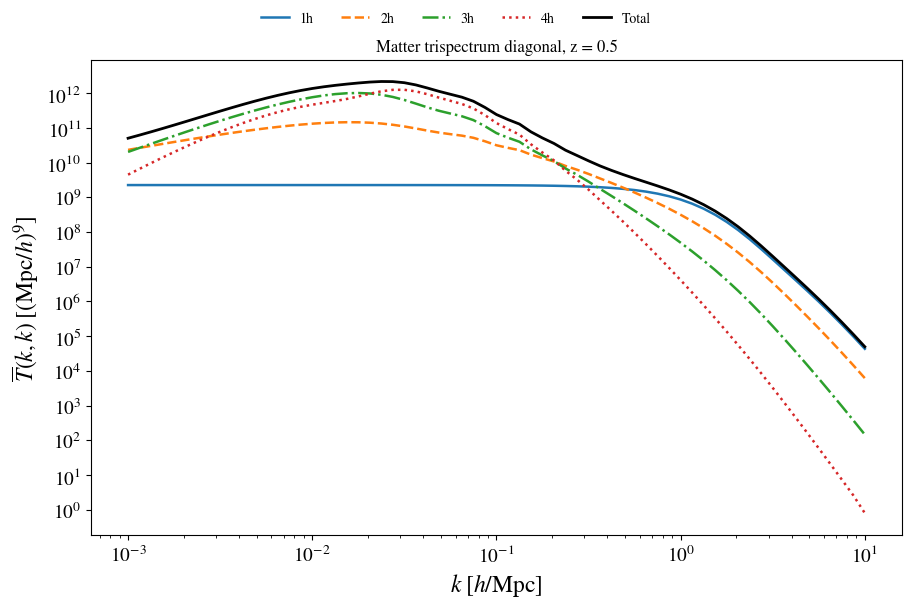

In [3]:
halo_redshift = 0.5
halo_scale_factor = 1.0/(1.0+halo_redshift)
k_hmpc = np.geomspace(start=1.e-3, stop=10.0, num=65)

# c/H0 is 2997.92458 Mpc/h: the factor h is already in the length unit.
# A trispectrum has nine powers of length, whereas power has three.
cover_h0_mpc_over_h = 2997.92458
k_core = k_hmpc*cover_h0_mpc_over_h
halo_terms = cov.halo_trispectrum(
    interface=ci,
    a=halo_scale_factor,
    k=k_core,
    lnm_edges=settings["lnm_edges"],
    accuracy_boost=settings["accuracy_boost"],
    mnu=settings["cosmology"]["mnu"],
    integration_accuracy=settings["integration_accuracy"],
)
terms_mpc_over_h9 = halo_terms["terms"]*cover_h0_mpc_over_h**9

# The five rows distinguish the two possible two-halo partitions.
# Every row uses the same triangular ordering of wavenumber pairs.
T1h = terms_mpc_over_h9[0]
T2h_13 = terms_mpc_over_h9[1]
T2h_22 = terms_mpc_over_h9[2]
T3h = terms_mpc_over_h9[3]
T4h = terms_mpc_over_h9[4]
T2h = T2h_13+T2h_22

# Equal pair indices select q=k, in the order of the original k grid.
diagonal_pairs = halo_terms["first"] == halo_terms["second"]
halo_diagonal = {
    "1h": T1h[diagonal_pairs],
    "2h": T2h[diagonal_pairs],
    "3h": T3h[diagonal_pairs],
    "4h": T4h[diagonal_pairs],
}
pcov.plot_trispectrum_terms(
    k_hmpc=k_hmpc,
    components=halo_diagonal,
    redshift=halo_redshift,
)


## Compute G, SSC, cNG and their sum

G describes covariance made from pairs of two-point spectra. It includes the shot noise of the lens catalog, the Poisson term $1/n$ of a finite number density $n$, and the shape noise of the sources, $\sigma_\epsilon^2/n$ from their intrinsic ellipticity scatter. SSC couples measurements through a background density fluctuation larger than the footprint. cNG is the remaining connected four-point contribution in the adopted halo model.

Angular bins are consecutive within each observable. The Fourier companion uses one E-mode row per source pair, with integer multipoles weighted by $2\ell+1$ inside each band. A Fourier-space CosmoLike likelihood evaluates its mean spectrum at logarithmic band centers; the generated covariance instead averages integer modes within bands, so it is an analogous bandpower calculation.

Each computation retains internal cross-bin spectra even when the corresponding observable is absent from the measured vector. The loop below changes only numerical resolution, and stores all physical components at each requested boost.

In [4]:
# Each space uses its own projection. Changing the boost refines tables
# while preserving cosmology, observable ordering and measured bins.
results = {}
for space in spaces:
    if space not in ['real', 'fourier']:
        raise ValueError("Choose a measurement space supported by this adapter")
    results[space] = {}
    for boost in boosts:
        refined = dict(settings)
        refined.update(cov.covariance_accuracy(
            accuracy_boost=boost, **settings["accuracy_parameters"],
        ))
        # Reinstall the power tables at this boost, so their k grid
        # is refined along with the covariance integration tables.
        camb_tables = survey.initialize(interface=ci, settings=refined)
        ci.set_omp_threads(n=8)
        print(space, "accuracy boost", boost)
        results[space][boost] = survey.compute(
            interface=ci, settings=refined, space=space, progress=progress,
        )

native_space = 'real'
forecast = results[native_space][boosts[-1]]
print("Full covariance shape:", forecast["total"].shape)

real accuracy boost 1


    1.96 s  all_pairs_gaussian_spectra


    2.45 s  angular_and_mask_geometry


    5.80 s  gaussian_blocks


    6.01 s  observable_signal


...

  149.77 s  Matter shell 577/672


  157.81 s  Matter shell 609/672


  165.50 s  Matter shell 641/672


  172.88 s  shared_halo_response_and_trispectrum


  173.14 s  ssc_and_connected_projection
  173.15 s  total
Full covariance shape: (1500, 1500)


## Apply the project's likelihood cuts

The supplied mask selects measurements, so the same selection must act on both axes of G, SSC, cNG and their sum. Removing the masked rows and columns compacts each matrix to 635 × 635; the saved `indices` record the original file position of every retained entry. Probe labels refer to contiguous groups in the uncut likelihood vector, including any measured-pair exclusions.

For files of CosmoCov, the standalone covariance code whose text files list Gaussian and non-Gaussian columns separately, the reader adds the two columns. It does not guess how the combined non-Gaussian column divides into SSC and cNG.

The first figure shows correlation coefficients $C_{ij}/\sqrt{C_{ii}C_{jj}}$, each matrix normalized by its own diagonal. The computed total fills the lower matrix triangle (row > column) and the supplied total the upper one, as the title states. The image puts index 0 at the bottom left, so on screen the computed triangle lies above the drawn diagonal and the supplied triangle below it. The second figure divides each component by the diagonal of the total, $C^{\rm component}_{ij}/\sqrt{C^{\rm total}_{ii}C^{\rm total}_{jj}}$, in maps and one histogram. Differences here are **not** a numerical convergence test. The split-triangle layout follows [Friedrich et al., Fig. 6](https://arxiv.org/abs/2012.08568); the component maps adapt [Barreira, Krause & Schmidt, Fig. 1](https://arxiv.org/abs/1807.04266). The last lines print whether each matrix is positive definite, with its smallest correlation eigenvalue.

Supplied file size: 1809
Retained comparison size: 635
Mask: DESY3xPlanckR4_6x2pt_Maglim_baseline_archive.mask


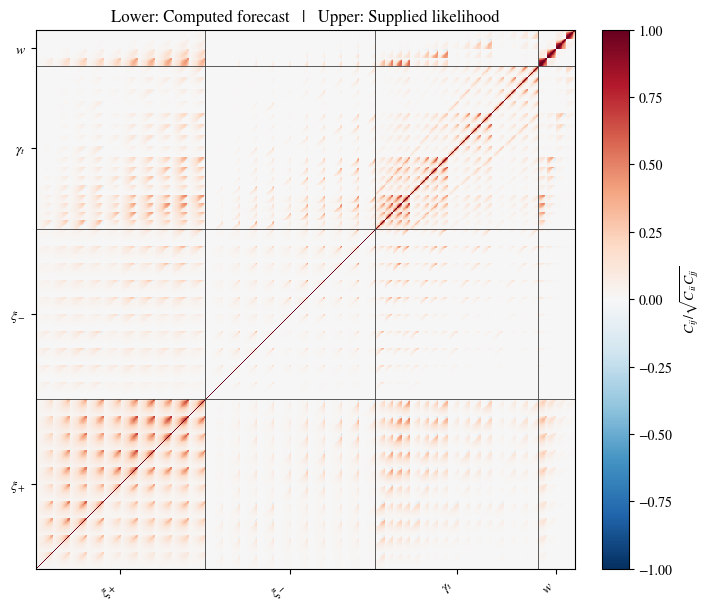

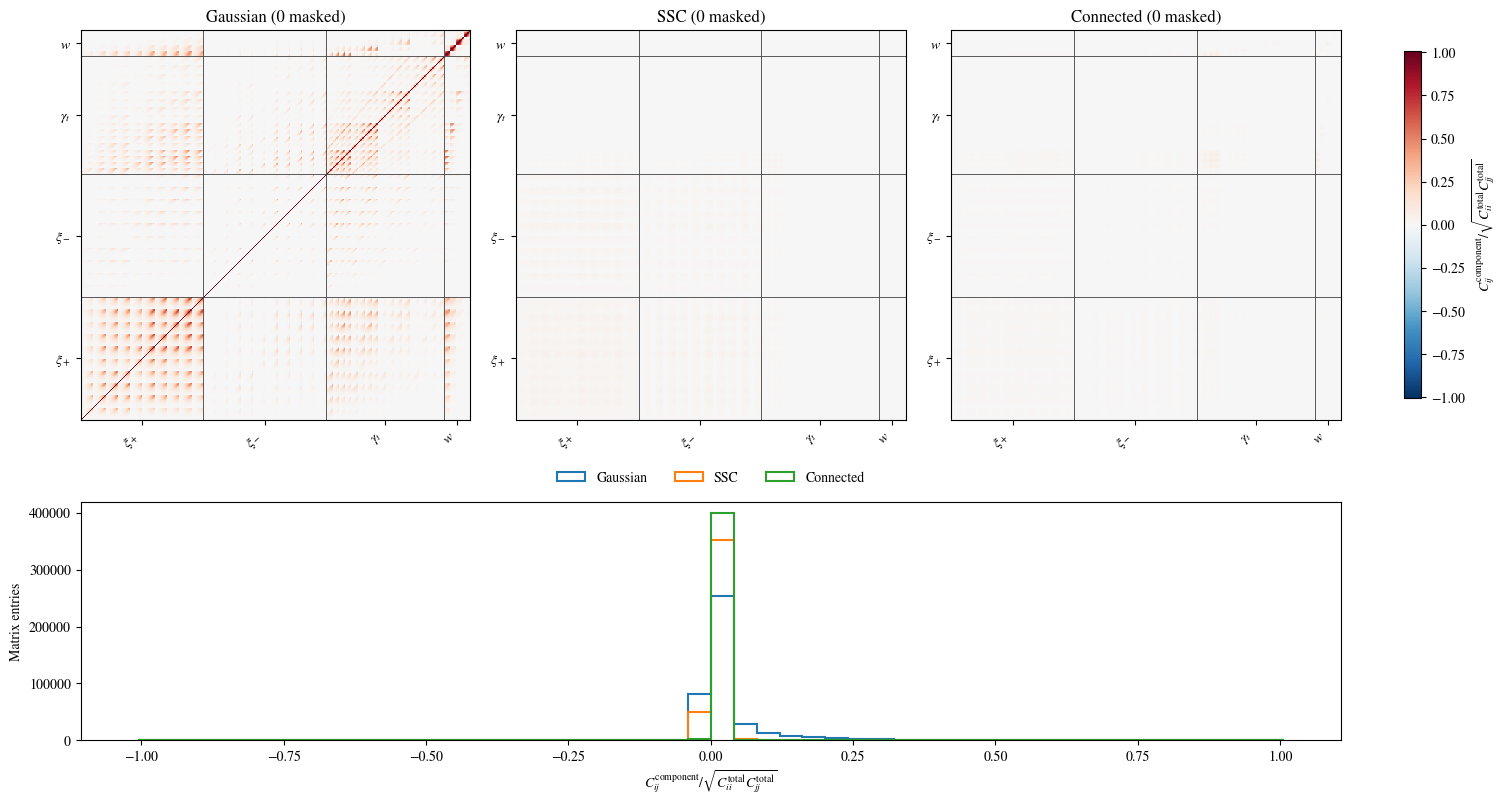

total positive definite: True minimum correlation eigenvalue: 0.007107624144520136
supplied positive definite: True minimum correlation eigenvalue: 0.005559630700869627


In [5]:
# size=1500 reads the leading galaxy/shear block of the 1,809-entry file;
# the CMB-lensing rows have no computed counterpart.
supplied = read_likelihood_covariance(dataset=dataset, size=1500)
# xi_+ and xi_- (10 source pairs x 30 angles each), gamma_t (24 lens-source
# pairs x 30) and w (6 lens bins x 30), in data-vector order.
block_sizes = [300, 300, 720, 180]
block_labels = ['$\\xi_+$', '$\\xi_-$', '$\\gamma_t$', '$w$']
selected = select_likelihood_entries(
    forecast=forecast,
    supplied=supplied,
    block_sizes=block_sizes,
    block_labels=block_labels,
)
print("Supplied file size:", supplied["file_size"])
print("Retained comparison size:", len(selected["indices"]))
print("Mask:", Path(supplied["mask_file"]).name)

pcov.plot_correlation(
    covariance=selected["total"],
    covariance_ref=selected["supplied"],
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    labels=("Computed forecast", "Supplied likelihood"),
)
pcov.plot_covariance_components(
    total=selected["total"],
    components={
        "Gaussian": selected["gaussian"],
        "SSC": selected["ssc"],
        "Connected": selected["cng"],
    },
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    normalization="diagonal",
)

for label in ("total", "supplied"):
    modes = cov.covariance_modes(matrix=selected[label])
    print(label, "positive definite:", modes["positive_definite"],
          "minimum correlation eigenvalue:", modes["correlation_eigenvalues"][0])

## Inspect the eigenvalues of each matrix

`cov.covariance_modes` returns more than the positivity flag printed above: the smallest variance (`minimum_diagonal`), the raw eigenvalues in the units of the matrix and the eigenvalues of the correlation matrix $R_{ij}=C_{ij}/\sqrt{C_{ii}C_{jj}}$. Dividing each measurement by its standard deviation is an invertible change of units, so $R$ has as many negative eigenvalues as $C$. Its eigenvalues are dimensionless and average to one, so shear, lensing and clustering share one scale. The ratio of the largest to the smallest correlation eigenvalue, the condition number, measures how strongly inverting the matrix in a likelihood amplifies small errors in it.

The total must be positive definite; its components need not be. G is expected to be positive definite, because its noise terms add variance to every measurement. SSC is a weighted sum of outer products $\mathbf r\mathbf r^{\mathsf T}$ of response vectors with nonnegative weights, so it is positive semidefinite: its eigenvalues are nonnegative up to roundoff, and it can be nearly singular. cNG can be indefinite on its own. The axis of the figure is logarithmic above $10^{-6}$ and linear below, so zero and negative eigenvalues stay visible instead of vanishing from a logarithmic plot. Nothing is clipped or regularized.

In [ ]:
# Correlation eigenvalues of every cut matrix, in ascending order.
figure, axis = plt.subplots(figsize=(7, 4), constrained_layout=True)
for label in ("total", "supplied", "gaussian", "ssc", "cng"):
    modes = cov.covariance_modes(matrix=selected[label])
    values = modes["correlation_eigenvalues"]
    if values is None:
        print(label, "has a nonpositive variance:", modes["minimum_diagonal"])
        continue
    print(label, "positive definite:", modes["positive_definite"],
          "smallest:", values[0], "largest:", values[-1])
    axis.plot(values, label=label)
# Logarithmic above 1e-6 and linear below, so zero and negative modes stay visible.
axis.set_yscale("symlog", linthresh=1.e-6)
axis.set(xlabel="Mode, in ascending order", ylabel="Correlation eigenvalue")
axis.legend()

## Compare the selected entries with the supplied matrix

`select_likelihood_entries` keeps the same entries of the computed components and of the supplied total. `selected["indices"]` holds their positions in the uncut 1,500-entry vector and `selected["block_sizes"]` the number retained per probe. The correlation figure above hides differences in amplitude, because it divides each matrix by its own diagonal; the next two cells compare amplitudes directly.

- The figure shows the ratio of standard deviations $\sigma^{\rm computed}_i/\sigma^{\rm supplied}_i$ entry by entry, with grey lines between probes and a dark line at 1.
- The generalized eigenvalues $\lambda$ of $C_{\rm computed}v=\lambda\,C_{\rm supplied}v$ bound the variance ratio $v^{\mathsf T}C_{\rm computed}v\,/\,v^{\mathsf T}C_{\rm supplied}v$ over every linear combination $v$ of the retained measurements, including the combinations a likelihood weights most.

Both comparisons mix the different physical choices of the two matrices with numerical differences; they describe the forecast, not its convergence.

In [ ]:
# Retained entries per probe and the first original file positions.
for block in range(len(selected["block_sizes"])):
    print(selected["block_labels"][block], selected["block_sizes"][block], "entries")
print("First retained file positions:", selected["indices"][:5])

# Ratio of standard deviations, entry by entry, in likelihood order.
sigma_ratio = np.sqrt(np.diag(selected["total"])/np.diag(selected["supplied"]))
figure, axis = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
axis.plot(sigma_ratio, marker=".", linestyle="none")
# Running totals of the block sizes, without the last, are the probe boundaries.
for boundary in np.cumsum(selected["block_sizes"])[:-1]:
    axis.axvline(x=boundary-0.5, color="0.5", linewidth=0.8)
axis.axhline(y=1.0, color="0.3", linewidth=0.8)
axis.set(xlabel="Retained entry, in likelihood order",
         ylabel=r"$\sigma_i^{\rm computed}/\sigma_i^{\rm supplied}$")

In [ ]:
# Generalized eigenvalues of C_computed v = lambda C_supplied v. The supplied
# matrix is the reference because it is positive definite: the 3x2pt
# likelihood inverts this same selection.
change = cov.compare_covariances(
    matrix=selected["total"], reference=selected["supplied"],
)
ratios = change["generalized_eigenvalues"]
print("Variance ratio computed/supplied over all directions:",
      ratios[0], "to", ratios[-1])
print("Median of the", len(ratios), "eigenvalues:", np.median(ratios))

## Two more covariance figures

Two options of `plot_covariances` that the rest of the notebook does not use:

- `plot_covariance_diagonal` without a reference draws $\sqrt{C_{ii}}$ against angle. For a component, $\sqrt{C_{ii}}$ is the square root of its contribution to the variance. Applied to the uncut forecast for $\xi_+$ of the first source-bin pair, it shows which term dominates the error bar at each scale, beside the supplied total. The function refuses a nonpositive variance instead of clipping it, so such a component is reported rather than drawn.
- `plot_covariance_components` with `normalization="element"` divides each component by the total entry by entry, $C^{\rm component}_{ij}/C^{\rm total}_{ij}$, here in percent, as in Fig. 1 of Barreira, Krause & Schmidt. Where the total nearly cancels, such a ratio measures the cancellation rather than the component, so `denominator_floor=0.05` masks in grey every entry whose total correlation $|C^{\rm total}_{ij}|/\sqrt{C^{\rm total}_{ii}C^{\rm total}_{jj}}$ is below 5%. The masking is display-only.

In [ ]:
# Square root of each variance contribution for xi_+ of source pair (1,1),
# the first 30 entries of the uncut vector, beside the supplied total.
nbin = 30
curves = {}
for name in ("gaussian", "ssc", "cng", "total"):
    block = forecast[name][:nbin, :nbin]
    if np.all(np.diag(block) > 0):
        curves[name] = block
    else:
        print(name, "has a nonpositive variance in this panel and is not drawn")
curves["supplied"] = supplied["total"][:nbin, :nbin]
pcov.plot_covariance_diagonal(
    theta_arcmin=forecast["coordinate"], covariances=curves,
    panel_labels=["$\\xi_+$ (1,1)"], coordinate_label=forecast["coordinate_label"],
)

In [ ]:
# Element ratios C_component/C_total in percent. denominator_floor=0.05 masks
# (grey) entries whose total correlation is below 5%: there the total nearly
# cancels, and the ratio would measure the cancellation, not the component.
pcov.plot_covariance_components(
    total=selected["total"],
    components={
        "Gaussian": selected["gaussian"],
        "SSC": selected["ssc"],
        "Connected": selected["cng"],
    },
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    normalization="element", denominator_floor=0.05, percent=True,
)

## Check changes with accuracy boost

With two or more boosts, the next cell compares the *computed* matrices after the same likelihood cuts. The highest tested boost is a comparison reference. Generalized eigenvalues solve $C_b v=\lambda\,C_{\rm ref}v$ and bound the variance ratio $v^{\mathsf T}C_bv\,/\,v^{\mathsf T}C_{\rm ref}v$ for every linear combination $v$ of retained measurements. The reported maximum departure from one is a fraction; 0.01 means 1%.

The error-bar panel selects $\xi_+$ of the first source-bin pair (1,1), the first 30 entries of the uncut vector. It shows the percent change of $\sqrt{C_{ii}}$ relative to the highest boost. This illustrates why convergence needs more than diagonal agreement. Refine quadrature separately at fixed boost, and eventually check marginalized Fisher errors and the Figure of Merit, the inverse area of a marginalized two-parameter error ellipse. No matrix here has its eigenvalues clipped or its diagonal repaired.

In [6]:
if len(boosts) == 1:
    print("Set boosts = [1, 2] above and rerun to compare numerical accuracy.")
else:
    for boost in boosts:
        current = select_likelihood_entries(
            forecast=results[native_space][boost],
            supplied=supplied,
            block_sizes=block_sizes,
            block_labels=block_labels,
        )
        change = cov.compare_covariances(
            matrix=current["total"], reference=selected["total"],
        )
        print(boost, "maximum fractional variance change:",
              change["maximum_fractional_variance_change"])

    # The first observable is the first source auto-correlation, with
    # all its angular bins or Fourier bands consecutive in the full vector.
    nbin = 30
    reference = forecast["total"][:nbin, :nbin]
    curves = {}
    for boost in boosts[:-1]:
        curves[f"Boost {boost} / {boosts[-1]}"] = (
            results[native_space][boost]["total"][:nbin, :nbin]
        )
    coordinate = forecast["coordinate"]
    pcov.plot_covariance_diagonal(
        theta_arcmin=coordinate,
        covariances=curves,
        panel_labels=['$\\xi_+$'],
        covariance_ref=reference,
        coordinate_label='$\\ell$' if native_space == "fourier" else '$\\theta\\;[\\mathrm{arcmin}]$',
    )

Set boosts = [1, 2] above and rerun to compare numerical accuracy.


## Inspect the C++ notebook interface

The compiled wrappers take vectors, matrices and cubes (three-dimensional arrays) of Armadillo, a C++ linear-algebra library, with named physical axes. Python converts NumPy inputs into owned Armadillo arrays, copies that the C++ side manages itself; these notebook copies are intentional. Whole Gaussian matrices and individual projection, halo and response components are available for independent experiments. The help text gives dimensions and units.

In [7]:
help(ci.covariance_gaussian_fourier)
help(ci.covariance_project)
help(ci.covariance_halo_response)

Help on built-in function covariance_gaussian_fourier in module cosmolike_desy1xplanck_interface:

covariance_gaussian_fourier(...) method of builtins.PyCapsule instance
    covariance_gaussian_fourier(spectra: object, noise: object, pairs: object, operators: object, ell_min: int, area_sr: float) -> Numpy.ndarray[numpy.float64]
    
    Compute a Gaussian bandpower matrix from supplied field spectra.
    
    spectra[ell,field,field] contains observed signal on consecutive integer
    multipoles starting at ell_min>=0. noise[field] is independent white
    shot/shape power. pairs[observable,2] contains field IDs (A,B).
    operators[band,ell] supplies normalized band weights; the supplied bands
    may overlap. area_sr is the common survey area in steradians.
    Use float64 arrays and int32 pairs. Internal crossed spectra
    are required even when excluded from the measured bandpower vector.
    
    Returns an owned symmetric [nobservable*nband,nobservable*nband] matrix,
    with ba

## Save the calculation

The archives retain each physical component, ordering, physical assumptions and resolved accuracy settings; `forecast_camb.npz` keeps the CAMB input tables. The separate likelihood-selection archive contains the compact matrices, original entry indices and the supplied total used in the plot. Only files in `covariance/` are written; the supplied files in `data/` remain unchanged. Running this cell again replaces the computed archives. The last section reads them back.

In [8]:
for space in spaces:
    save_forecast(
        result=results[space][boosts[-1]],
        filename=project/"covariance"/f"forecast_{space}.npz",
    )
np.savez(file=project/"covariance/forecast_camb.npz", **camb_tables)
np.savez(
    file=project/"covariance/forecast_likelihood_selection.npz",
    **selected,
    dataset=str(dataset.relative_to(project)),
    accuracy_boost=boosts[-1],
)
print("Saved covariance components and likelihood selection.")

Saved covariance components and likelihood selection.


## Reload the saved archives

An `.npz` file is a NumPy archive: several named arrays in one file. The next cell reads both archives back with `allow_pickle=False`, which refuses stored Python objects, and checks that every saved array equals the one still in memory. The resolved settings travel with the matrices as JSON text (`settings_json`), so a later session can confirm the measurement space and accuracy boost of a matrix before reusing it, without recomputing anything.

In [ ]:
import json

# Read both archives back and compare them with the arrays in memory.
saved = results[native_space][boosts[-1]]
folder = project/"covariance"
archive = np.load(file=folder/f"forecast_{native_space}.npz", allow_pickle=False)
for name in ("gaussian", "ssc", "cng", "total", "signal", "rows", "coordinate"):
    print(name, "identical:", np.array_equal(archive[name], saved[name]))
stored = json.loads(str(archive["settings_json"]))
print("Stored space and accuracy boost:", stored["space"], stored["accuracy_boost"])
archive.close()
reloaded = np.load(file=folder/"forecast_likelihood_selection.npz", allow_pickle=False)
for name in ("indices", "total", "supplied", "gaussian", "ssc", "cng"):
    print("selection", name, "identical:", np.array_equal(reloaded[name], selected[name]))
reloaded.close()